In [1]:
#import statements and formatting
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['pdf.fonttype'] = 42

# Read the Excel file
df = pd.read_excel("Source_Data_CXCL12_placenta.xlsx", index_col=0, sheet_name = "Fig_4I")

Contingency Table:
           wild type  heterozygous  mutant  vehicle  CXCR4 inhibitor
no defect          6            14       3       22               15
defect             0             0       2        0                8


Summary Statistics:
Total embryos analyzed: 70

By genotype/treatment:
  wild type: 6 embryos, 0 defects (0.0%)
  heterozygous: 14 embryos, 0 defects (0.0%)
  mutant: 5 embryos, 2 defects (40.0%)
  vehicle: 22 embryos, 0 defects (0.0%)
  CXCR4 inhibitor: 23 embryos, 8 defects (34.8%)


Pairwise Comparisons (Fisher's Exact Test):
Bonferroni-corrected significance level: p < 0.005 (for 10 comparisons)

wild type vs heterozygous:
  Odds Ratio: nan (95% CI: N/A)
  P-value: 1.0000
  Not significant

wild type vs mutant:
  Odds Ratio: inf (95% CI: N/A)
  P-value: 0.1818
  Not significant

wild type vs vehicle:
  Odds Ratio: nan (95% CI: N/A)
  P-value: 1.0000
  Not significant

wild type vs CXCR4 inhibitor:
  Odds Ratio: inf (95% CI: N/A)
  P-value: 0.1477
  Not signi

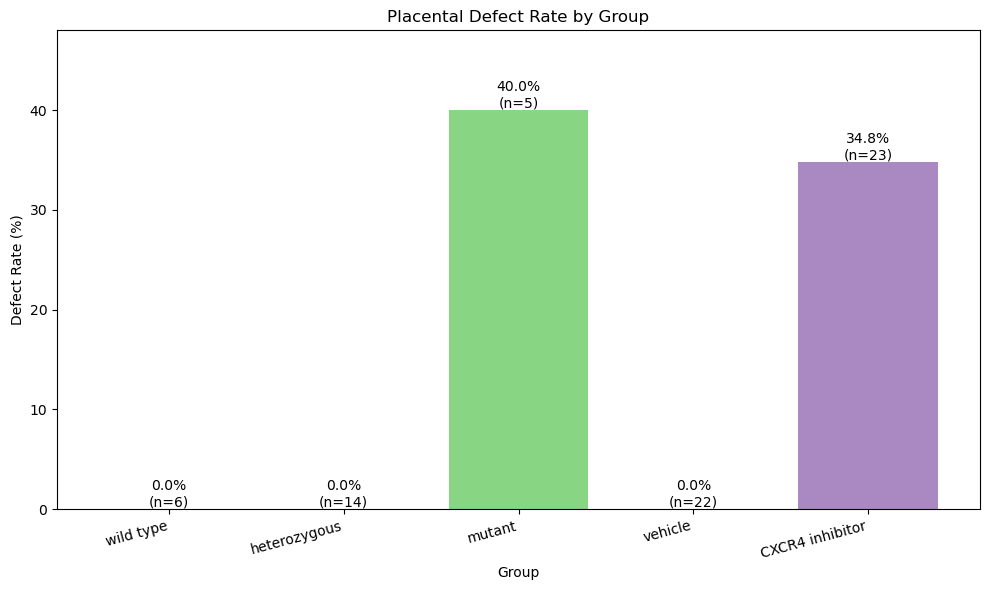

In [2]:
print("Contingency Table:")
print(df)
print("\n" + "="*60 + "\n")

contingency_table = df.values
row_totals = contingency_table.sum(axis=1)
col_totals = contingency_table.sum(axis=0)
grand_total = contingency_table.sum()

print("Summary Statistics:")
print(f"Total embryos analyzed: {grand_total}")
print("\nBy genotype/treatment:")
for i, group in enumerate(df.columns):
    n_total = col_totals[i]
    n_defect = contingency_table[1, i] 
    pct_defect = (n_defect / n_total * 100) if n_total > 0 else 0
    print(f"  {group}: {n_total} embryos, {n_defect} defects ({pct_defect:.1f}%)")

print("\n" + "="*60 + "\n")

print("Pairwise Comparisons (Fisher's Exact Test):")
print("Bonferroni-corrected significance level: p < 0.005 (for 10 comparisons)\n")

comparisons = [
    ("wild type", "heterozygous", 0, 1),
    ("wild type", "mutant", 0, 2),
    ("wild type", "vehicle", 0, 3),
    ("wild type", "CXCR4 inhibitor", 0, 4),
    ("heterozygous", "mutant", 1, 2),
    ("heterozygous", "vehicle", 1, 3),
    ("heterozygous", "CXCR4 inhibitor", 1, 4),
    ("mutant", "vehicle", 2, 3),
    ("mutant", "CXCR4 inhibitor", 2, 4),
    ("vehicle", "CXCR4 inhibitor", 3, 4)
]

pairwise_results = []
for name1, name2, idx1, idx2 in comparisons:
    subtable = contingency_table[:, [idx1, idx2]]
    
    oddsratio, p_fisher = fisher_exact(subtable)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        if oddsratio > 0 and oddsratio != float('inf') and not np.isnan(oddsratio):
            log_or = np.log(oddsratio)
            se_log_or = np.sqrt(np.sum(1.0 / (subtable + 0.5)))
            ci_lower = np.exp(log_or - 1.96 * se_log_or)
            ci_upper = np.exp(log_or + 1.96 * se_log_or)
            ci_str = f"[{ci_lower:.2f}, {ci_upper:.2f}]"
        else:
            ci_str = "N/A"
    
    print(f"{name1} vs {name2}:")
    print(f"  Odds Ratio: {oddsratio:.3f} (95% CI: {ci_str})")
    print(f"  P-value: {p_fisher:.4f}")
    
    if p_fisher < 0.005:
        print(f"  *** Significant after Bonferroni correction (p < 0.005)")
    elif p_fisher < 0.05:
        print(f"  * Nominally significant (p < 0.05) but not after correction")
    else:
        print(f"  Not significant")
    print()
    
    pairwise_results.append({
        'Comparison': f"{name1} vs {name2}",
        'Odds Ratio': f"{oddsratio:.3f}" if oddsratio != float('inf') and not np.isnan(oddsratio) else ('inf' if oddsratio == float('inf') else 'NaN'),
        '95% CI': ci_str,
        'P-value': p_fisher, # Keep as float for easy formatting
        'Significant': '***' if p_fisher < 0.005 else ('*' if p_fisher < 0.05 else 'ns')
    })

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df['P-value'] = pairwise_df['P-value'].apply(lambda x: f"{x:.4f}")
print("\nPairwise Comparison Summary:")
print(pairwise_df.to_string(index=False))

print("\n" + "="*60 + "\n")

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

genotypes = df.columns
defect_rates = []
for i, genotype in enumerate(genotypes):
    n_total = col_totals[i]
    n_defect = contingency_table[1, i]
    rate = (n_defect / n_total * 100) if n_total > 0 else 0
    defect_rates.append(rate)

bars = ax.bar(genotypes, defect_rates, alpha=0.8, color=sns.color_palette("muted"))

ax.set_ylabel('Defect Rate (%)')
ax.set_xlabel('Group')
# Removed the overall p-value from the title since we skipped the 2xN exact test
ax.set_title('Placental Defect Rate by Group') 
ax.set_ylim([0, max(defect_rates) * 1.2 if max(defect_rates) > 0 else 100])
plt.xticks(rotation=15, ha='right') 

for i, (bar, rate) in enumerate(zip(bars, defect_rates)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1f}%\n(n={col_totals[i]})',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()